In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tensorflow import keras

C:\Users\hemas\anaconda3\envs\new_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
mnist = keras.datasets.mnist
(xtr_all, ytr_all), (xte_all, yte_all) = mnist.load_data()

In [15]:
xtr_all.shape, ytr_all.shape, xte_all.shape, yte_all.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
xtr_all[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

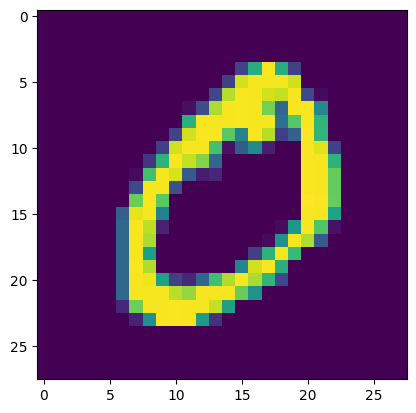

In [5]:
plt.imshow(xtr_all[1])

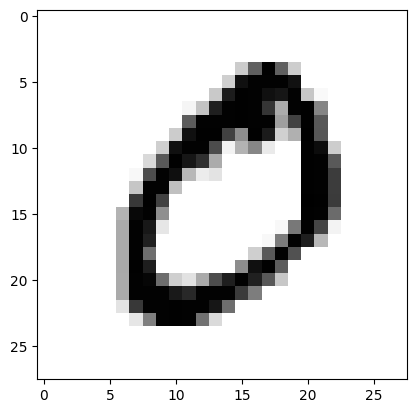

In [6]:
plt.imshow(xtr_all[1], cmap = 'binary')

<Axes: >

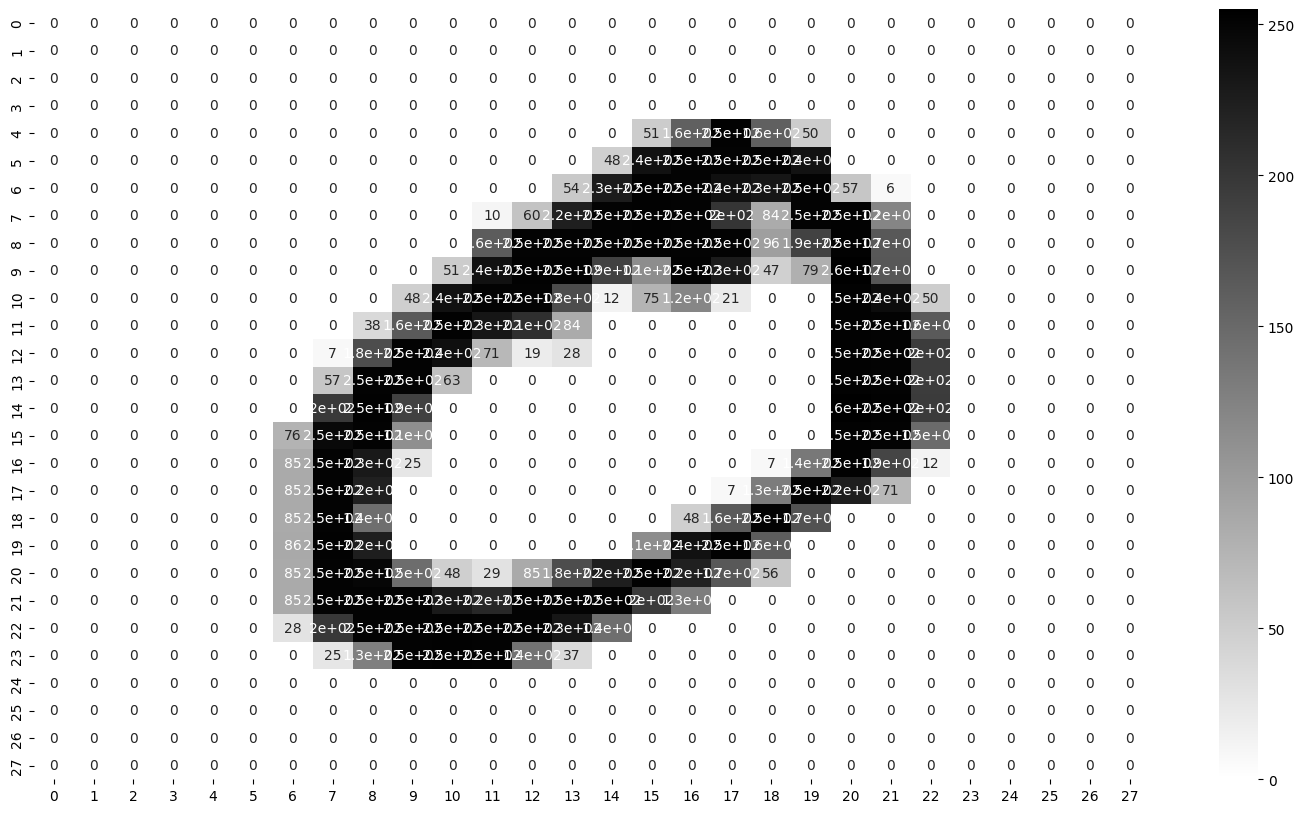

In [12]:
plt.figure(figsize = (18, 10))
sns.heatmap(xtr_all[1], annot = True, cmap = 'binary')

<Axes: >

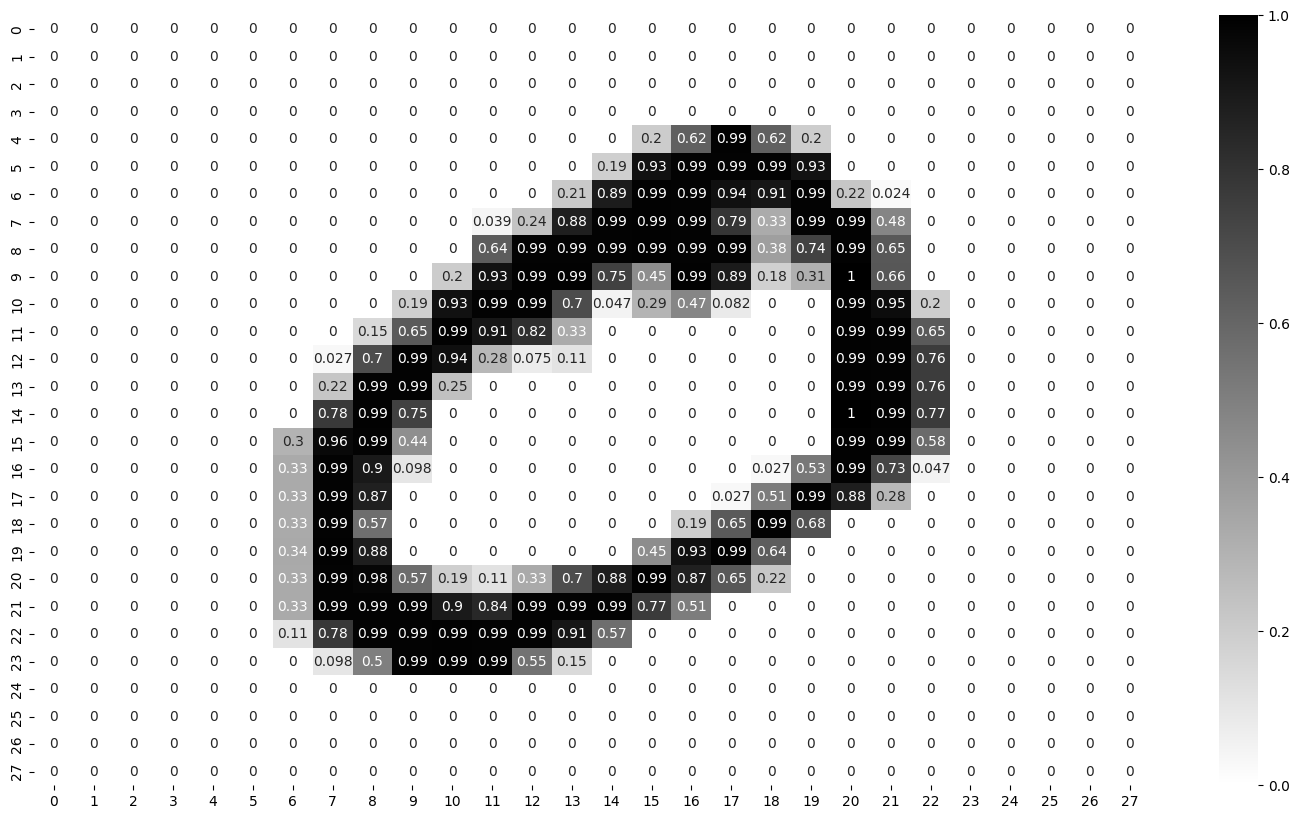

In [13]:
xtr = xtr_all/255.0
plt.figure(figsize = (18, 10))
sns.heatmap(xtr[1], annot = True, cmap = 'binary')

In [17]:
x_val, xtrain = xtr[:5000], xtr[5000:]
y_val, ytrain = ytr_all[:5000], ytr_all[5000:]

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten

In [36]:
model = Sequential(
    [
        # Flatten(input_shape = (28, 28), name = "input flatten layer"),
        Flatten(input_shape=(28,28), name='input_flatten_layer'),
        Dense(300, activation = 'relu', name = "Hidden_layer1"),
        Dense(128, activation = 'relu', name = "Hidden_layer2"),
        Dense(64, activation = 'relu', name = "Hidden_layer3"),
        Dense(32, activation = 'relu', name = "Hidden_layer4"),
        Dense(16, activation = 'relu', name = "Hidden_layer5"),
        Dense(10, activation = 'softmax', name = "Softmax_Layer")
    ]
)

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_flatten_layer (Flatten)        │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer1 (Dense)                │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer2 (Dense)                │ (None, 128)                 │          38,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer3 (Dense)                │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer4 (Dense)                │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer5 (Dense)                │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Softmax_Layer (Dense)                │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 285,062 (1.09 MB)

 Trainable params: 285,062 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
loss = tf.keras.losses.SparseCategoricalCrossentropy()
opt = tf.keras.optimizers.Adam()
metr = ['accuracy']

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(xtr, ytr_all, batch_size = 32, epochs = 20, verbose = 1, validation_data = (x_val, y_val))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9211 - loss: 0.2674 - val_accuracy: 0.9708 - val_loss: 0.0892
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9695 - loss: 0.1031 - val_accuracy: 0.9844 - val_loss: 0.0546
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9776 - loss: 0.0739 - val_accuracy: 0.9866 - val_loss: 0.0478
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9819 - loss: 0.0576 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9849 - loss: 0.0483 - val_accuracy: 0.9880 - val_loss: 0.0406
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9880 - loss: 0.0391 - val_accuracy: 0.9928 - val_loss: 0.0213
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9895 - loss: 0.0350 - val_accuracy: 0.9948 - val_loss: 0.0178
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0317 -

In [42]:
xte = xte_all/255.0

In [44]:
model.evaluate(xte, yte_all)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.1121


[0.11212628334760666, 0.9797999858856201]

In [45]:
x_test = xtr[:3]
y_test = yte_all[:3]

In [46]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


In [47]:
y_pred

array([[8.9894243e-15, 2.5738290e-11, 1.9719723e-17, 6.5189454e-10,
        1.2145639e-16, 1.0000000e+00, 5.8770752e-11, 2.3861552e-13,
        1.3687407e-10, 6.3427203e-14],
       [1.0000000e+00, 5.5008863e-25, 5.8727735e-18, 2.7820251e-13,
        6.2415838e-15, 2.1378127e-18, 4.6689774e-10, 3.3250030e-13,
        7.3072460e-12, 8.9378218e-16],
       [6.2514538e-10, 1.5676375e-15, 4.1392939e-10, 6.1595227e-18,
        1.0000000e+00, 4.1012082e-15, 2.5736817e-11, 3.2246415e-16,
        4.1901116e-16, 4.9679822e-12]], dtype=float32)

In [48]:
y_pred.round()

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [49]:
model.save("mnist_ann.h5")

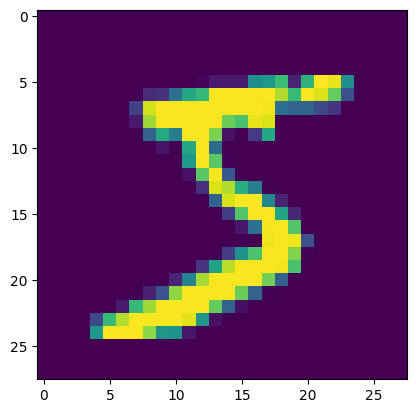

In [50]:
plt.imshow(x_test[0])